In [1]:
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [2]:
# clone github code
!git clone https://github.com/tabetant/aps360_pokedex.git
%cd aps360_pokedex

Cloning into 'aps360_pokedex'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 83 (delta 33), reused 70 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (83/83), 17.22 KiB | 1.32 MiB/s, done.
Resolving deltas: 100% (33/33), done.
/content/aps360_pokedex


In [3]:
!git -C /content/aps360_pokedex pull

Already up to date.


In [4]:
# mount Drive and pull the dataset zip to LOCAL disk, then unzip
from google.colab import drive
drive.mount('/content/drive')
!rm -rf /content/data                     # clear the messy earlier extract
!cp "/content/drive/MyDrive/aps360_project/dataset.zip" /content/
!unzip -q /content/dataset.zip -d /content
!ls /content/data | head                  # data root is now /content/data

Mounted at /content/drive
cache
processed


In [5]:
# smoke test lora model
from src.pokedex.models.lora import build_lora_model, make_lora_embed, encode
import torch

m = build_lora_model()                 # expect: "LoRA on 24 modules", trainable <1%
x = torch.randn(2, 3, 256, 256)
m.train()
f = encode(m, x)
print("train encode:", f.shape, "norms:", f.norm(dim=-1), "grad:", f.requires_grad)
print("eval encode:", make_lora_embed(m)(x).shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/276 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


tokenizer_config.json:   0%|          | 0.00/47.2k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

LoRA on 24 modules (r=8, alpha=16); trainable params: 294,912 || all params: 375,528,962 || trainable%: 0.0785
train encode: torch.Size([2, 768]) norms: tensor([1., 1.], device='cuda:0', grad_fn=<LinalgVectorNormBackward0>) grad: True
eval encode: torch.Size([2, 768])


In [6]:
from src.pokedex.models.lora import build_lora_model, make_lora_embed, encode, save_adapters
from src.pokedex.models.losses import info_nce
from src.pokedex.data.pairs import make_pair_loader
from src.pokedex.eval.retrieval import build_grid, summarize_grid
import torch, json

EPOCHS = 12

In [7]:
import os, json
os.chdir('/content')        # so the manifest's relative "data/..." image paths resolve
manifest = json.load(open('data/processed/manifest.json'))
print(len(manifest), "records;", manifest[0])   # expect 3324

3324 records; {'species_id': 1, 'generation': 'generation-i', 'style': 'retropixel', 'image_path': 'data/processed/1/retropixel.png', 'names': {'ja-hrkt': 'フシギダネ', 'ko': '이상해씨', 'fr': 'Bulbizarre', 'de': 'Bisasam', 'es': 'Bulbasaur', 'it': 'Bulbasaur', 'en': 'Bulbasaur'}, 'split': 'train'}


In [8]:
torch.manual_seed(0)        # for reproducibility1

model = build_lora_model()
optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad])

HIST_PATH = '/content/drive/MyDrive/aps360_project/history.json'
best, history = -1, []

for epoch in range(EPOCHS):
    model.train()
    loader = make_pair_loader(manifest, batch_size=32, seed=epoch, num_workers=2)
    running = 0.0
    for anchor, positive, sids in loader:
        fa = encode(model, anchor); fb = encode(model, positive)
        loss = info_nce(fa, fb)
        loss.backward(); optimizer.step(); optimizer.zero_grad()
        running += loss.item()
    train_loss = running / len(loader)

    s = summarize_grid(build_grid(manifest, embed_fn=make_lora_embed(model),
                                  query_split='val', use_cache=False))
    s['epoch'] = epoch; s['train_loss'] = train_loss
    history.append(s)
    json.dump(history, open(HIST_PATH, 'w'), indent=2)
    print(epoch, train_loss, s)

    if s['retro_mean'] > best and s['modern_min'] >= 0.83:
        best = s['retro_mean']
        save_adapters(model, '/content/drive/MyDrive/aps360_project/lora_best')

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

LoRA on 24 modules (r=8, alpha=16); trainable params: 294,912 || all params: 375,528,962 || trainable%: 0.0785


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


0 0.2557243849609939 {'retro_mean': 0.7657657663027445, 'retro_min': 0.7027027010917664, 'modern_mean': 0.9877851406733195, 'modern_min': 0.9666666388511658, 'n_retro_cells': 6, 'n_modern_cells': 6, 'epoch': 0, 'train_loss': 0.2557243849609939}
1 0.029391043386618857 {'retro_mean': 0.7972972889741262, 'retro_min': 0.7297297120094299, 'modern_mean': 0.9877777794996897, 'modern_min': 0.9666666388511658, 'n_retro_cells': 6, 'n_modern_cells': 6, 'epoch': 1, 'train_loss': 0.029391043386618857}
2 0.017457528997370055 {'retro_mean': 0.7747747798760732, 'retro_min': 0.7297297120094299, 'modern_mean': 0.9844518105189005, 'modern_min': 0.9599999785423279, 'n_retro_cells': 6, 'n_modern_cells': 6, 'epoch': 2, 'train_loss': 0.017457528997370055}
3 0.012180245802803358 {'retro_mean': 0.7837838033835093, 'retro_min': 0.7567567825317383, 'modern_mean': 0.9866666793823242, 'modern_min': 0.9733333587646484, 'n_retro_cells': 6, 'n_modern_cells': 6, 'epoch': 3, 'train_loss': 0.012180245802803358}
4 0.0096

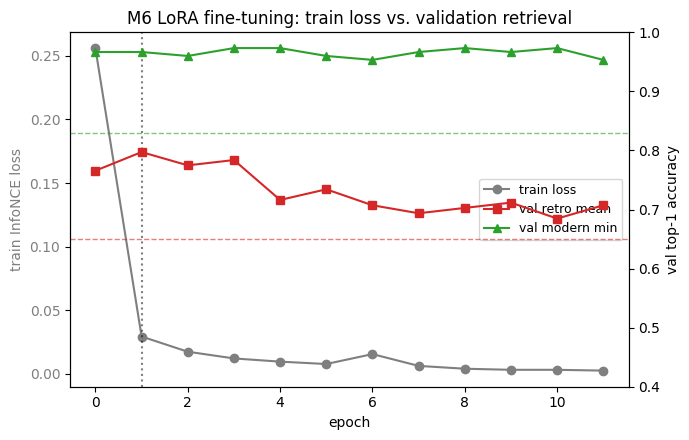

In [9]:
import json, matplotlib.pyplot as plt

H  = json.load(open('/content/drive/MyDrive/aps360_project/history.json'))
ep = [h['epoch'] for h in H]
tl = [h['train_loss']  for h in H]
rm = [h['retro_mean']  for h in H]
mm = [h['modern_min']  for h in H]
best_ep = max(H, key=lambda h: h['retro_mean'])['epoch']

fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(ep, tl, 'o-', color='tab:gray', label='train loss')
ax1.set_xlabel('epoch'); ax1.set_ylabel('train InfoNCE loss', color='tab:gray')
ax1.tick_params(axis='y', labelcolor='tab:gray')

ax2 = ax1.twinx()
ax2.plot(ep, rm, 's-', color='tab:red',   label='val retro mean')
ax2.plot(ep, mm, '^-', color='tab:green', label='val modern min')
ax2.axhline(0.65, ls='--', lw=1, color='tab:red',   alpha=.6)   # retro target
ax2.axhline(0.83, ls='--', lw=1, color='tab:green', alpha=.6)   # modern guard
ax2.set_ylabel('val top-1 accuracy'); ax2.set_ylim(0.4, 1.0)
ax1.axvline(best_ep, ls=':', color='black', alpha=.5)

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lab1+lab2, loc='center right', fontsize=9)
plt.title('M6 LoRA fine-tuning: train loss vs. validation retrieval')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/aps360_project/m6_curves.png', dpi=200)
plt.show()

In [10]:
from src.pokedex.models.lora import load_lora_model, make_lora_embed
from src.pokedex.eval.retrieval import build_grid, summarize_grid

best = load_lora_model('/content/drive/MyDrive/aps360_project/lora_best')
test = summarize_grid(build_grid(manifest, embed_fn=make_lora_embed(best),
                                 query_split='test', use_cache=False))
print(test)

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

{'retro_mean': 0.6794871985912323, 'retro_min': 0.6666666865348816, 'modern_mean': 0.9811386267344157, 'modern_min': 0.9496855139732361, 'n_retro_cells': 6, 'n_modern_cells': 6}
